In [8]:
import numpy as np
from sklearn.metrics import accuracy_score
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler , OneHotEncoder

In [2]:
# from tensorflow.keras.datasets import mnist

# (X_train , y_train) , (x_test , y_test) = mnist.load_data()

In [3]:
# x_train , x_val , y_train , y_val = train_test_split(X_train , y_train , test_size=0.2 , random_state=42)

In [4]:
# print('x_train [shape %s] sample patch: \n' %(str(x_train.shape)) , x_train[1,15:20 , 5:10])
# plt.imshow(x_train[1,15:20 , 5:10] ,cmap='grey')
# plt.show()

In [ ]:
# Normalize the Images
from tensorflow.keras.datasets import mnist

# Pre processing data - 1 Scaling the data
(X_train , y_train) , (x_test , y_test) = mnist.load_data()
x_train = X_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


# Reshaping the data
x_train = x_train.reshape(-1 , 784)
x_test = x_test.reshape(-1 , 784)

# one hot encoding for Target Y

y_train_oh = tf.keras.utils.to_categorical(y_train , 10)
y_test_oh = tf.keras.utils.to_categorical(y_test , 10)

model = tf.keras.Sequential([

    # Create some of hidden layers
    tf.keras.layers.Dense(500 , activation='sigmoid' , input_shape = (784,)), # H1
    tf.keras.layers.Dense(100 , activation='sigmoid'), # H2
    tf.keras.layers.Dense(10 , activation='softmax') # H3 LAST Layer, nodes are equal to the output shape

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,610 (1.69 MB)

 Trainable params: 443,610 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam' , loss= 'categorical_crossentropy' , metrics=['accuracy'])
history = model.fit(x_train , y_train_oh , batch_size=64, epochs=10 , validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8633 - loss: 0.5148 - val_accuracy: 0.9325 - val_loss: 0.2322
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9380 - loss: 0.2086 - val_accuracy: 0.9523 - val_loss: 0.1681
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9567 - loss: 0.1471 - val_accuracy: 0.9602 - val_loss: 0.1355
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9671 - loss: 0.1098 - val_accuracy: 0.9660 - val_loss: 0.1142
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9761 - loss: 0.0836 - val_accuracy: 0.9702 - val_loss: 0.1029
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9802 - loss: 0.0650 - val_accuracy: 0.9735 - val_loss: 0.0896
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9855 - loss: 0.0497 - val_accuracy: 0.9736 - val_loss: 0.0858
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9890 - loss: 0.0384 - val_accuracy: 0.

In [12]:
test_loss , test_acc = model.evaluate(x_test , y_test_oh)
print("Test accuracy" , test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9788 - loss: 0.0777
Test accuracy 0.9787999987602234


In [13]:
def get_random_indices(total_images , num_images):
    return np.random.choice(total_images , num_images , replace=False)

# make Predictions
predictions = model.predict(x_test)

x_test_images = x_test.reshape(-1 , 28 ,28)
prediction_classes = np.argmax(predictions , axis=1)
true_classes = np.argmax(y_test_oh , axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step


In [14]:
num_images = 5
random_indices = get_random_indices(len(x_test_images) , num_images)


def plot_images(images , labels , predictions):
    plt.figure(figsize=(10,5))
    for i in range(len(images)):
        plt.subplot(1 , len(images) , i+1)
        plt.imshow(images[i] , cmap='grey')
        plt.title(f"True: {labels[i]}\n, Predicted: {predictions[i]}")
        plt.axis('off')
    plt.show()


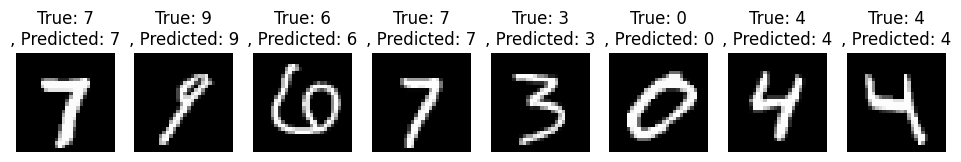

In [15]:
num_images = 8
random_indices = get_random_indices(len(x_test_images) , num_images)


def plot_images(images , labels , predictions):
    plt.figure(figsize=(12,8))
    for i in range(len(images)):
        plt.subplot(1 , len(images) , i+1)
        plt.imshow(images[i] , cmap='grey')
        plt.title(f"True: {labels[i]}\n, Predicted: {predictions[i]}")
        plt.axis('off')
    plt.show()

plot_images(x_test_images[random_indices] , true_classes[random_indices] , prediction_classes[random_indices])

In [19]:
# evaluating results
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import TensorBoard

list_activity = ['sigmoid' , 'relu' , 'tanh']
list_optimizer = ['Adam' , 'SGD' , 'RMSprop']
list_loss = ['categorical_crossentropy', 'mean_squared_error']

# Pre processing data - 1 Scaling the data
(X_train , y_train) , (x_test , y_test) = mnist.load_data()
x_train = X_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshaping the data
x_train = x_train.reshape(-1 , 784)
x_test = x_test.reshape(-1 , 784)

# one hot encoding for Target Y

y_train_oh = tf.keras.utils.to_categorical(y_train , 10)
y_test_oh = tf.keras.utils.to_categorical(y_test , 10)

i = 1

accuracy_scores = []
for activity in list_activity:
    for optimizer in list_optimizer:
        for loss in list_loss:

            print(f"TRAIN LOG NUMBER: {i}, ACTIVATION FUNCTION: {activity}, OPTIMIZER: {optimizer}, LOSS: {loss}")
            NAME = f'mnist-28-28-v{i}'
            tensorboard = TensorBoard(log_dir='./logs/{}'.format(NAME) )
            model = tf.keras.Sequential([

                # Create some of hidden layers
                tf.keras.layers.Dense(500 , activation=activity , input_shape = (784,)), # H1
                tf.keras.layers.Dense(100 , activation=activity), # H2
                tf.keras.layers.Dense(10 , activation='softmax') # H3 LAST Layer, nodes are equal to the output shape

            ])

            model.compile(optimizer=optimizer , loss=loss , metrics=['accuracy'])
            history = model.fit(x_train , y_train_oh , batch_size=64, epochs=10 , validation_split=0.2 , callbacks=[tensorboard])

            test_loss , test_acc = model.evaluate(x_test , y_test_oh)
            print("Test accuracy" , test_acc)

            model_metrics = {
                'Activation': activity,
                'optimizer': optimizer,
                'model_accuracy_score': test_acc,
                'loss': loss
            }

            accuracy_scores.append(model_metrics)
            i +=1

TRAIN LOG NUMBER: 1, ACTIVATION FUNCTION: sigmoid, OPTIMIZER: Adam, LOSS: categorical_crossentropy
Epoch 1/10


c:\Users\Ahmed\Desktop\DEPI\DEPI Round 4\MLE SESSION TASKS\DEPI_Round4_AMIT_MLE\clean-repo\myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8696 - loss: 0.4934 - val_accuracy: 0.9301 - val_loss: 0.2442
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9387 - loss: 0.2079 - val_accuracy: 0.9423 - val_loss: 0.2002
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9555 - loss: 0.1485 - val_accuracy: 0.9605 - val_loss: 0.1375
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9665 - loss: 0.1110 - val_accuracy: 0.9654 - val_loss: 0.1174
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9748 - loss: 0.0852 - val_accuracy: 0.9713 - val_loss: 0.1001
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9808 - loss: 0.0659 - val_accuracy: 0.9736 - val_loss: 0.0877
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9850 - loss: 0.0513 - val_accuracy: 0.9737 - val_loss: 0.0887
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9886 - loss: 0.0400 - val_accuracy: 0.9751 - val_

In [21]:
acc_result = 0
best_activation = ''
best_optimizer = ''
best_loss = ''
for acc in accuracy_scores:
    
    print(acc , '\n')
    if acc_result < acc['model_accuracy_score']:
        acc_result = acc['model_accuracy_score']
        best_activation = acc['Activation']
        best_optimizer = acc['optimizer']
        best_loss = acc['loss']


print('-'*20)
print(f'Best Activation: {best_activation}, Best Optimizer: {best_optimizer} , Accuracy score: {acc_result} , Best loss: {best_loss}')


{'Activation': 'sigmoid', 'optimizer': 'Adam', 'model_accuracy_score': 0.9801999926567078, 'loss': 'categorical_crossentropy'} 

{'Activation': 'sigmoid', 'optimizer': 'Adam', 'model_accuracy_score': 0.9778000116348267, 'loss': 'mean_squared_error'} 

{'Activation': 'sigmoid', 'optimizer': 'SGD', 'model_accuracy_score': 0.8662999868392944, 'loss': 'categorical_crossentropy'} 

{'Activation': 'sigmoid', 'optimizer': 'SGD', 'model_accuracy_score': 0.14010000228881836, 'loss': 'mean_squared_error'} 

{'Activation': 'sigmoid', 'optimizer': 'RMSprop', 'model_accuracy_score': 0.9763000011444092, 'loss': 'categorical_crossentropy'} 

{'Activation': 'sigmoid', 'optimizer': 'RMSprop', 'model_accuracy_score': 0.9354000091552734, 'loss': 'mean_squared_error'} 

{'Activation': 'relu', 'optimizer': 'Adam', 'model_accuracy_score': 0.9771000146865845, 'loss': 'categorical_crossentropy'} 

{'Activation': 'relu', 'optimizer': 'Adam', 'model_accuracy_score': 0.9796000123023987, 'loss': 'mean_squared_err